In [1]:
print("Notebook Working")

Notebook Working


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.shape)

df.info()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

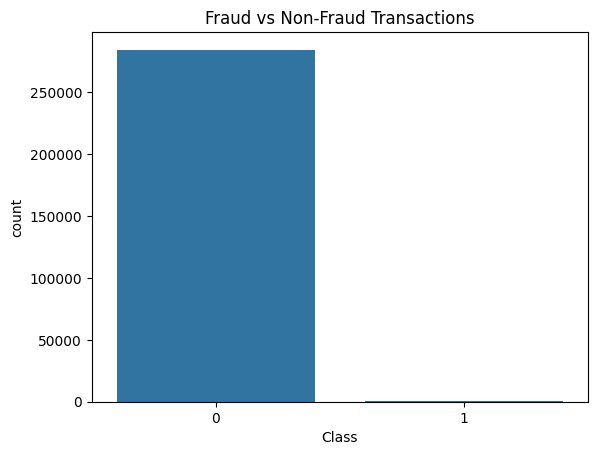

In [7]:
sns.countplot(x='Class', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

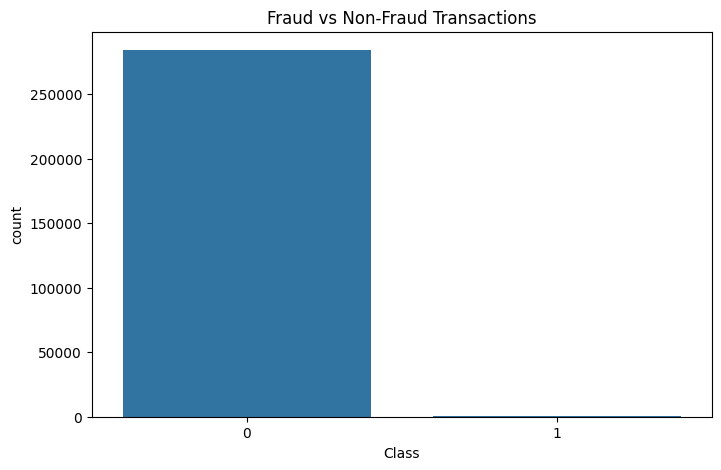

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.savefig("../reports/fraud_distribution.png")

plt.show()

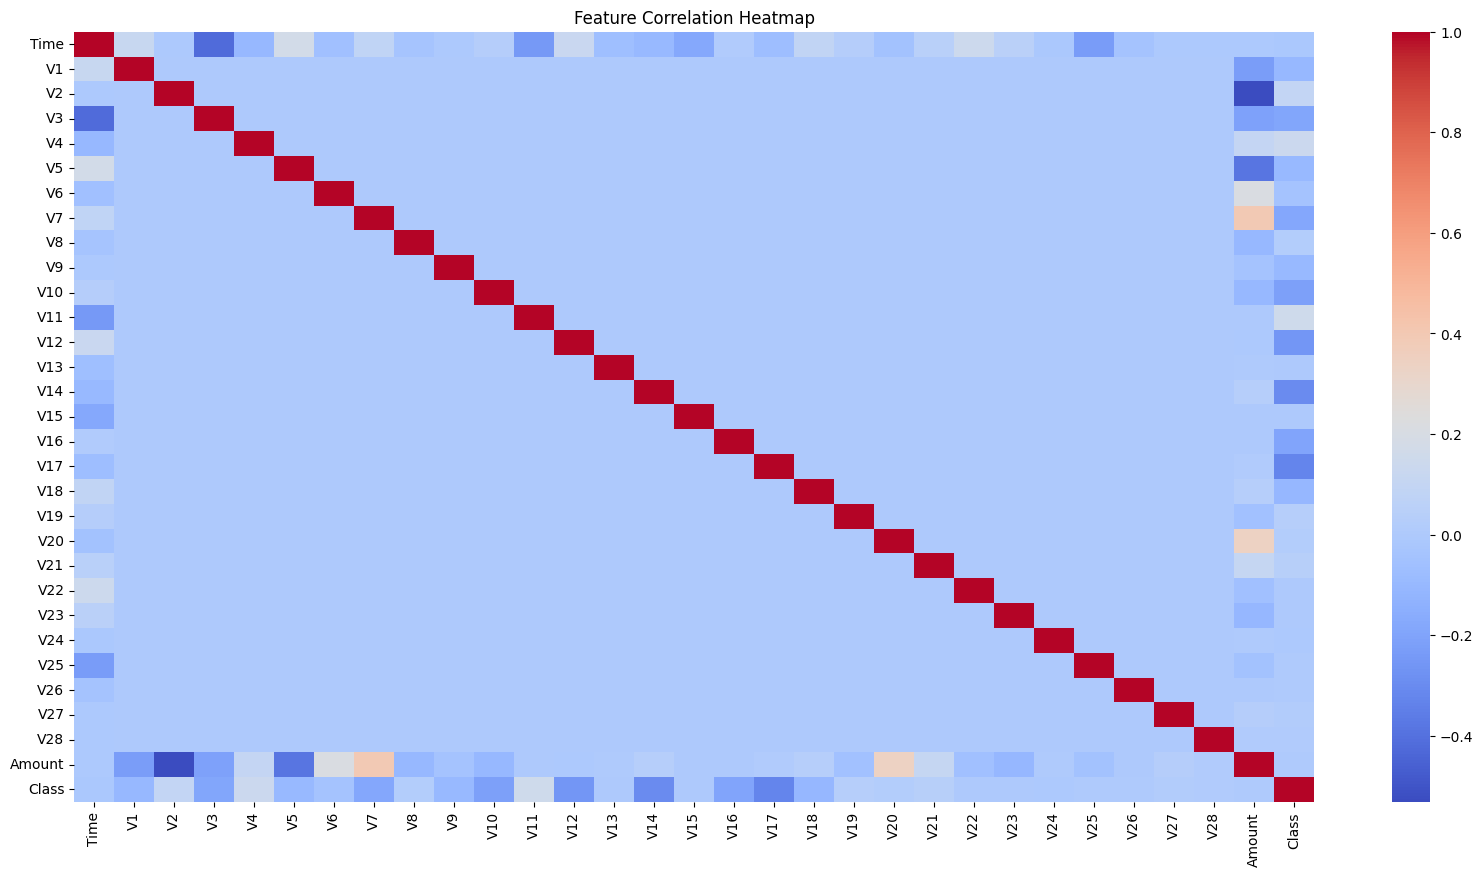

In [9]:
plt.figure(figsize=(20,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

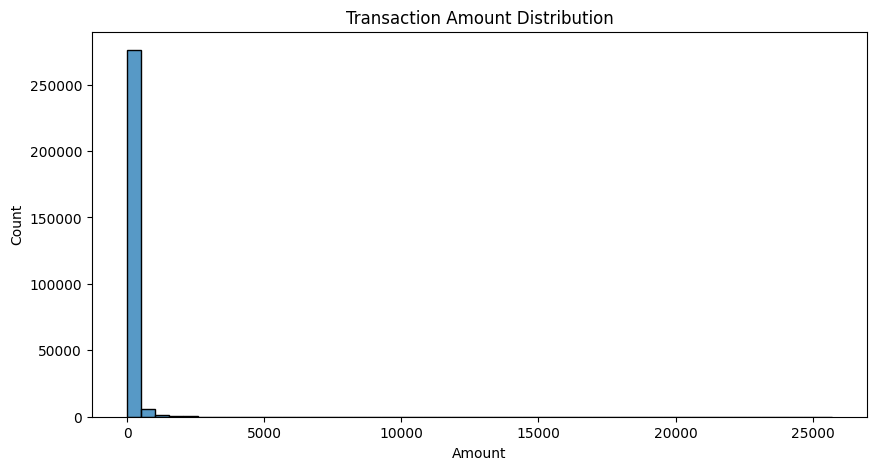

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

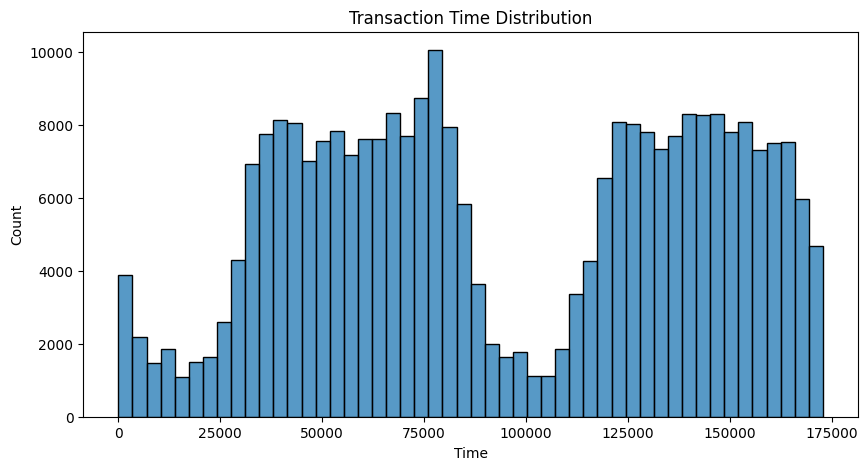

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

In [12]:
df['Amount_log'] = np.log1p(df['Amount'])

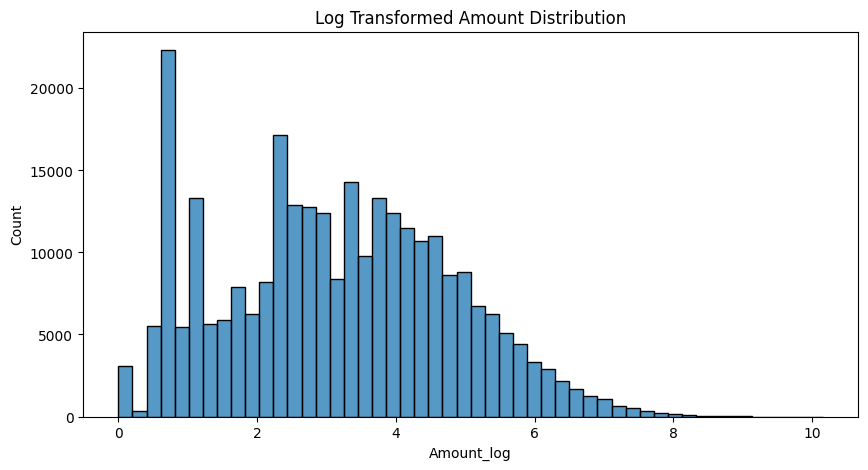

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount_log'], bins=50)

plt.title("Log Transformed Amount Distribution")

plt.show()

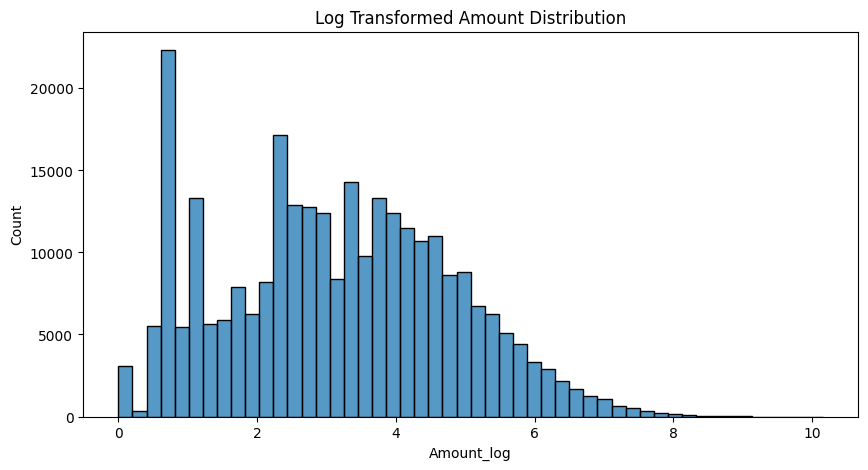

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount_log'], bins=50)

plt.title("Log Transformed Amount Distribution")

plt.savefig("../reports/amount_log_distribution.png")

plt.show()

In [15]:
X = df.drop('Class', axis=1)

y = df['Class']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(227845, 31)
(56962, 31)


In [17]:
print(y_train.value_counts())

print(y_test.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [19]:
print("Before SMOTE:")

print(y_train.value_counts())

print("\nAfter SMOTE:")

print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [20]:
processed_train = pd.concat(
    [
        pd.DataFrame(X_train_resampled),
        pd.DataFrame(y_train_resampled)
    ],
    axis=1
)

processed_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Amount_log,Class
0,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,2.118662,0
1,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,1.383791,0
2,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,5.171052,0
3,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,1.960095,0
4,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,4.467057,0


In [21]:
test_data = pd.concat(
    [
        pd.DataFrame(X_test),
        pd.DataFrame(y_test)
    ],
    axis=1
)

test_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Amount_log,Class
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00,3.178054,0
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,11.85,2.553344,0
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,76.07,4.344714,0
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.99,0.688135,0
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,1.50,0.916291,0


In [22]:
processed_train.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

test_data.to_csv(
    "../data/processed/test_processed.csv",
    index=False
)

## Data Preprocessing Insights

- The dataset exhibited severe class imbalance.
- SMOTE was applied to balance fraud samples.
- Log transformation improved skewed amount distribution.
- Stratified train-test split preserved fraud ratios.
- Processed datasets were saved for model training.